In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from scipy.signal import savgol_filter

from config import no_outlier_check, remote_features, insitu_features
from preparation import load_and_prepare_data, handle_duplicate_values, handle_outliers, reindex_daily, handle_missing_values, calculate_stats_from_random_points, smooth_data, merge_datasets, slice_by_dates

In [52]:
remote_df = load_and_prepare_data('../data/processed/satellites/Sentinel2_bands_indices_TCT_20m_202405-202605.csv')
remote_df = handle_duplicate_values(remote_df)
remote_df = reindex_daily(remote_df)
remote_df = handle_outliers(remote_df, 3.0)
remote_df = handle_missing_values(remote_df, 'time')
remote_df = calculate_stats_from_random_points(remote_df, 10)
remote_df = smooth_data(remote_df, None, 7, 2)

In [53]:
insitu_df = load_and_prepare_data('../data/processed/in-situ/SDH1_daily-insitu-data.csv')
insitu_df = handle_duplicate_values(insitu_df)
insitu_df = reindex_daily(insitu_df)
insitu_df = handle_outliers(insitu_df, 3.0, no_outlier_check)
insitu_df = handle_missing_values(insitu_df, 'time')

In [54]:
features = insitu_features + remote_features

fused_df = merge_datasets(insitu_df, remote_df)
fused_df = fused_df[features]
fused_df = slice_by_dates(fused_df, '2024-05-22', '2026-01-24')

In [55]:
z_df = fused_df.apply(zscore, nan_policy='omit')

In [56]:
z_df

,SDH1PS01_gw-depth_m,ATMOS41_precipitation_mm,brightness_mean,greenness_mean,wetness_mean
Timestamps,,,,,
2024-05-22,-0.798285,NaN,0.340764,-0.365307,0.274357
2024-05-23,-0.798285,NaN,0.401543,-0.438775,0.208151
2024-05-24,-0.821939,NaN,0.308357,-0.321847,0.347335
2024-05-25,-0.869248,NaN,0.276114,-0.234558,0.491124
2024-05-26,-0.940210,NaN,0.358988,-0.271161,0.529847
...,...,...,...,...,...
2026-01-20,-0.522320,0.662856,-2.269828,2.210444,1.021397
2026-01-21,-0.396165,4.966917,-2.502590,2.452339,1.309376
2026-01-22,-0.065007,9.552674,-2.683725,2.636859,1.486345


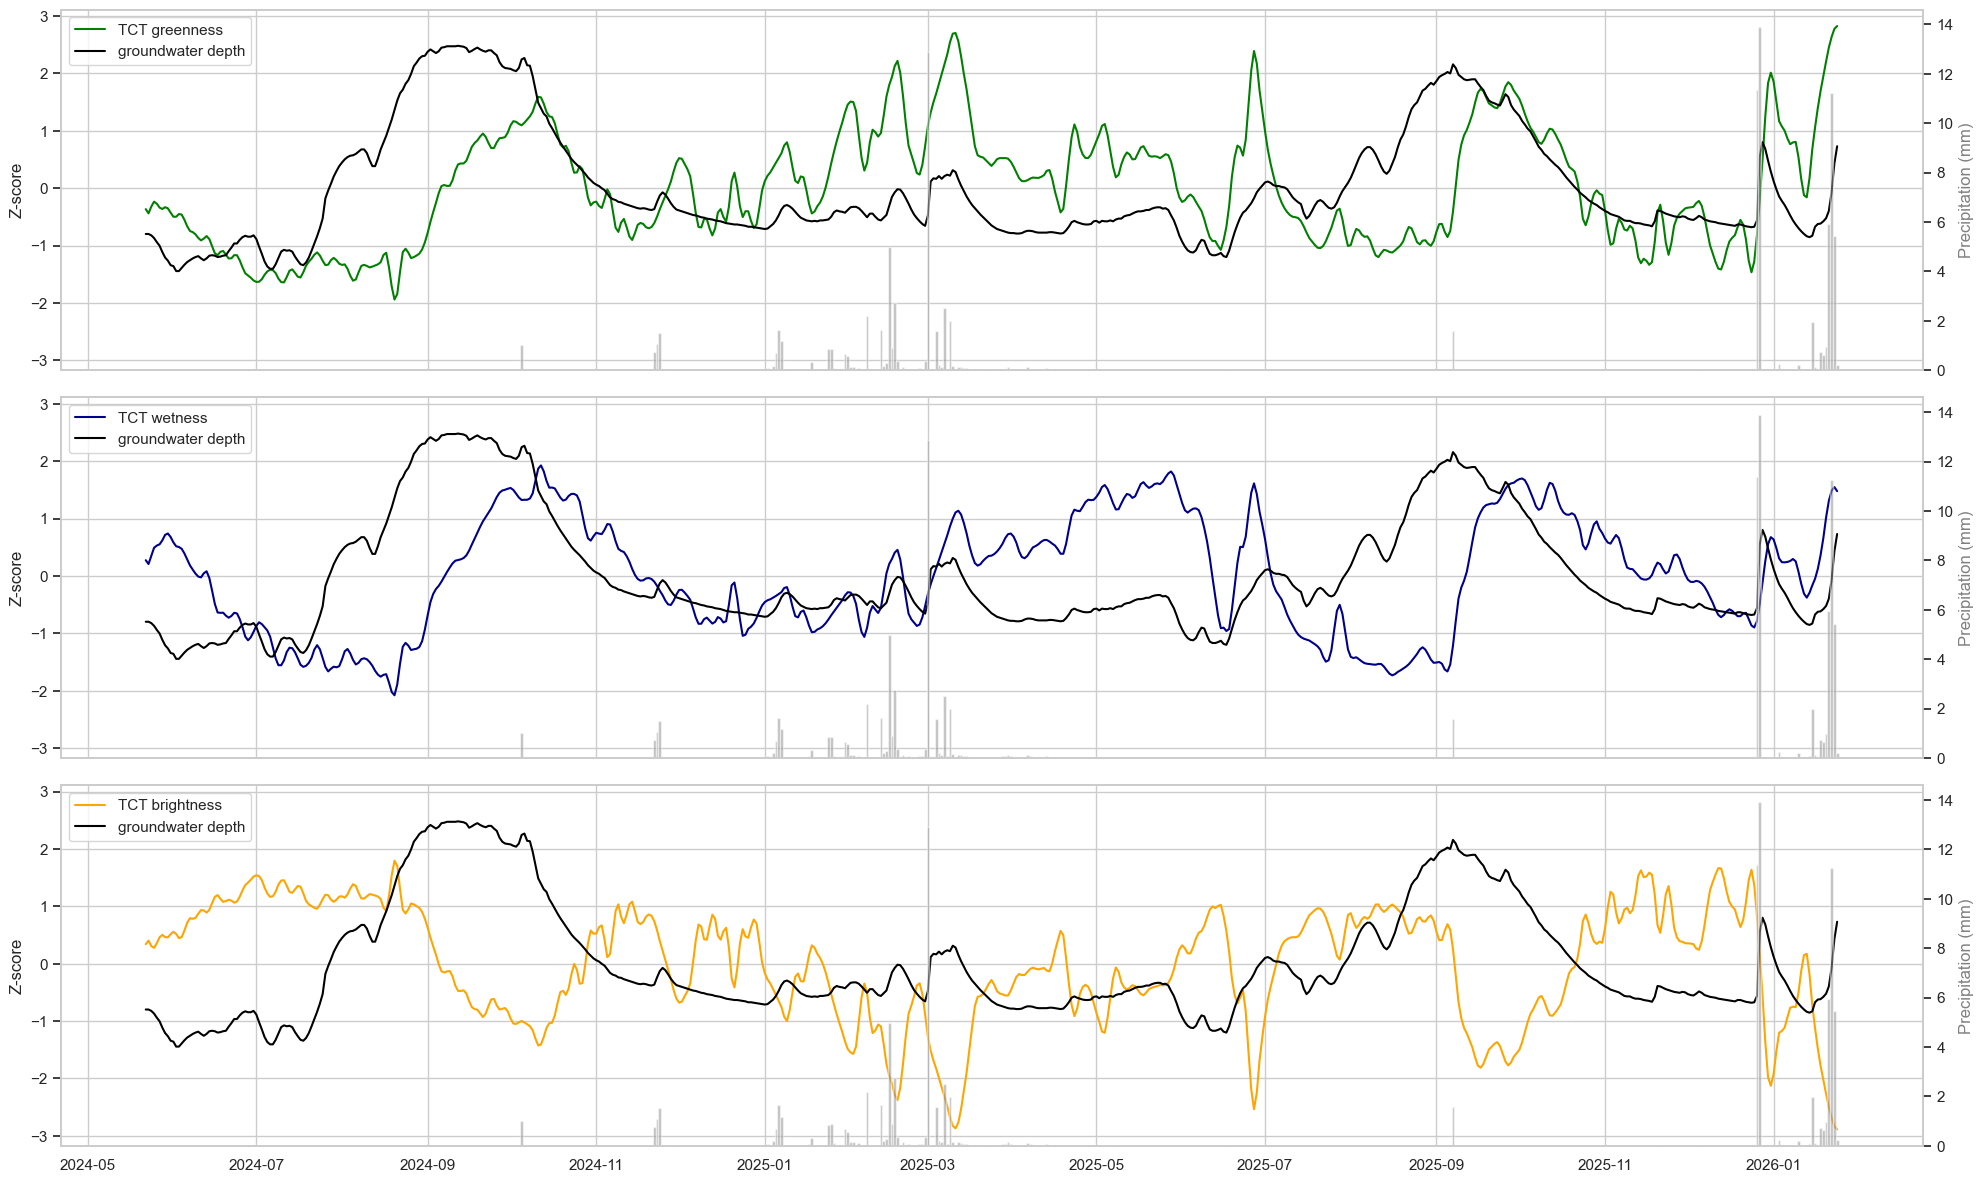

In [76]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(20,12), sharex=True, sharey=True)

ax1.plot(z_df.index, z_df['greenness_mean'], label='TCT greenness', c='green', alpha=1)
ax1.plot(z_df.index, z_df['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black', alpha=1)
ax1.set_ylabel('Z-score')
ax1.legend(loc='upper left')

ax2.plot(z_df.index, z_df['wetness_mean'], label='TCT wetness', c='darkblue', alpha=1)
ax2.plot(z_df.index, z_df['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black', alpha=1)
ax2.set_ylabel('Z-score')
ax2.legend(loc='upper left')

ax3.plot(z_df.index, z_df['brightness_mean'], label='TCT brightness', c='orange', alpha=1)
ax3.plot(z_df.index, z_df['SDH1PS01_gw-depth_m'], label='groundwater depth', c='black', alpha=1)
ax3.set_ylabel('Z-score')
ax3.legend(loc='upper left')

ax4 = ax1.twinx()
ax4.bar(fused_df.index, fused_df['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax4.set_ylabel('Precipitation (mm)', color='gray')
ax4.grid(False)

ax5 = ax2.twinx()
ax5.bar(fused_df.index, fused_df['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax5.set_ylabel('Precipitation (mm)', color='gray')
ax5.grid(False)

ax6 = ax3.twinx()
ax6.bar(fused_df.index, fused_df['ATMOS41_precipitation_mm'], width=1, color='gray', alpha=0.5, label='Precipitation (mm)')
ax6.set_ylabel('Precipitation (mm)', color='gray')
ax6.grid(False)

plt.grid(False)
plt.tight_layout()
plt.show()

In [58]:
def wide_to_long(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Transforms a dataframe from wide to long format, keeping the index as the identifier.
    """
    # Reset the index to temporal column to use it in melt
    df_reset = dataframe.reset_index()
    # Get the name of the index column
    index_name = df_reset.columns[0]

    # Melt the dataframe from wide to long format
    long_df = pd.melt(
        df_reset,
        id_vars=[index_name],
        var_name="feature",
        value_name='value',
    )
    return long_df

long_df = wide_to_long(fused_df)
long_df_z = wide_to_long(z_df)

In [60]:
def plot_mean_with_std(stats_df: pd.DataFrame, feature: str, nStd: int=1):
    """
    Plot the mean feature value over time with a shaded area representing +/- one standard deviation.
    """
    # Set a clean seaborn style for scientific plots
    sns.set_theme(style="whitegrid")
    
    # Initialize the matplotlib figure and axis
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Define the time axis (dataframe index) and the statistical series
    time_axis = stats_df.index
    mean = stats_df[f'{feature}_mean']
    std = stats_df[f'{feature}_std']
    
    # Calculate the upper and lower bounds for the standard deviation
    lower_bound = mean - (nStd*std)
    upper_bound = mean + (nStd*std)
    
    # Plot the mean line using seaborn
    sns.lineplot(
        x=time_axis, 
        y=mean, 
        label=f'mean {feature}', 
        color='gray',
        linewidth=1.3, 
        ax=ax
    )
    
    # Fill the area between lower and upper bounds using matplotlib
    ax.fill_between(
        time_axis, 
        lower_bound, 
        upper_bound, 
        color='gray',
        alpha=0.3,
        label='±1 std dev'
    )
    
    ax.set_ylabel(f'{feature} value')
    ax.set_xlabel('')
    ax.legend(loc='upper left', frameon=True)
    plt.tight_layout()
    
    plt.show()

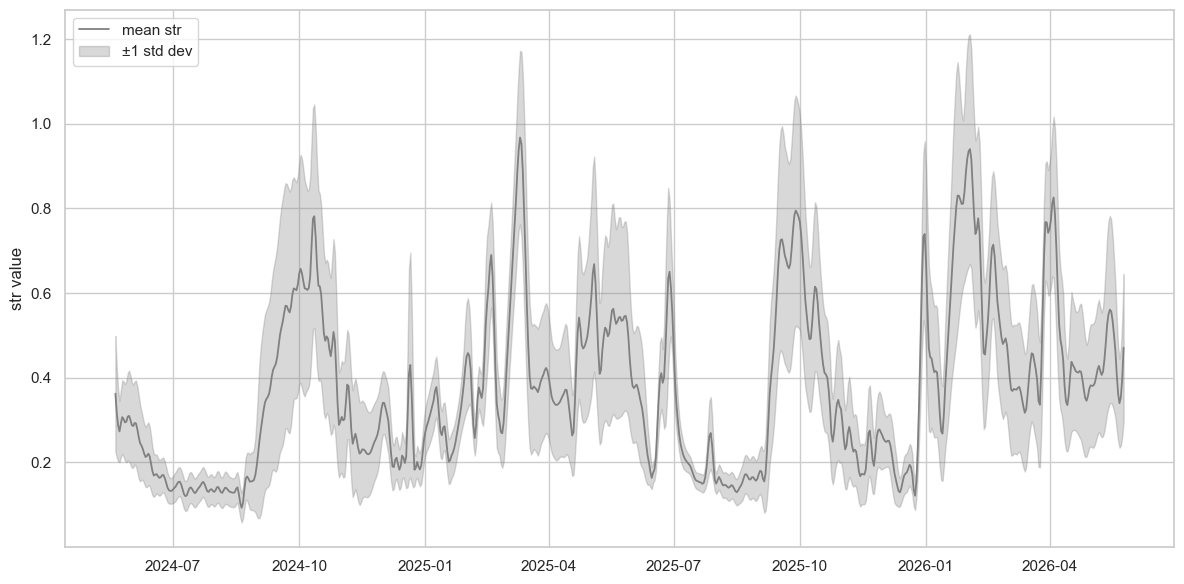

In [61]:
plot_mean_with_std(remote_df, 'str', 1)